In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [156]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

In [ ]:
sector = mid_prices.filter(regex=r'^ROBOT')
log_prices = np.log(sector)
a = log_prices.iloc[:, 0]
b = log_prices.iloc[:, 1]
c = log_prices.iloc[:, 2]
d = log_prices.iloc[:, 3]
e = log_prices.iloc[:, 4]
y5 = np.column_stack([a, b, c, d, e])

In [158]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y5, 0, 1)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [42.75819458 20.18204827 10.01290134  1.75495087]
Trace Critical Values: 
 [[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [22.57614631 10.16914693  8.25795048  1.75495087]
Max Eigenvalue Critical Values: 
 [[25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [159]:
beta = result.evec[:, 0]
beta

array([21.49543802, 15.13856007, 20.18404921, 23.25891288])

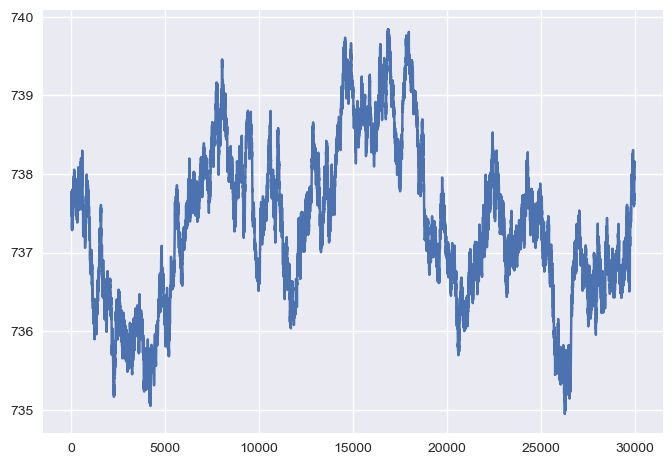

In [160]:
spread = y5 @ beta
plt.plot(spread)

In [161]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -3.501373680926379
Augmented Dickey Fuller p-value = 0.00795188503083204
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.43056803166244), '5%': np.float64(-2.861636364100729), '10%': np.float64(-2.566821291670243)}


In [162]:
spread.mean()

np.float64(737.347532936305)

In [163]:
spread.std()

np.float64(1.0004292574144173)

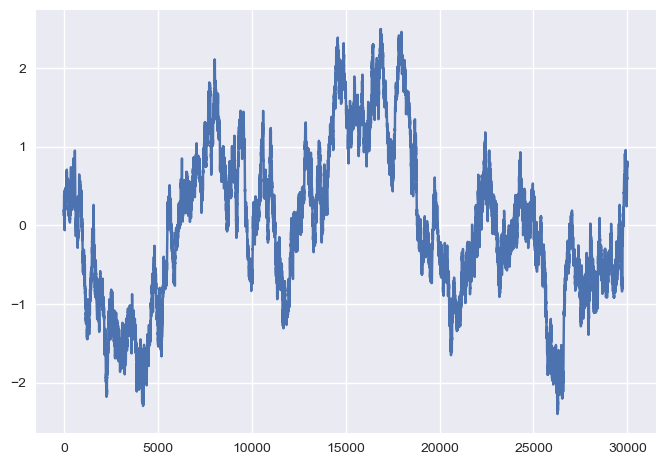

In [164]:
z_spread = (spread - spread.mean()) / spread.std()
plt.plot(z_spread)